In [122]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [123]:
df = pd.read_csv("../Data/train.csv")
df.shape

(28362, 24)

In [124]:
drop_cols = ["release_date", "age", "lyrics", "track_name", "artist_name", "genre", "topic"]
df.drop(columns=drop_cols, inplace=True, errors='ignore')
print("After drops, shape:", df.shape)


After drops, shape: (28362, 17)


Drop columns that are not needed for further analysis

We are removing age because we want to focus on thematic analysis

track_name, artist_name, genre, and topic dont have a score of 0-1 which won't help with our model training 

In [125]:
df.dropna(inplace=True)


In [126]:
df_variances = df.var()

In [127]:
threshold = 0.01
df_kept_cols = df_variances[df_variances >= threshold].index.tolist()
df_dropped_cols = df_variances[df_variances < threshold].index.tolist()

print("Keeping features with enough variation:", df_kept_cols)
print("Dropping features with low variation:", df_dropped_cols)


Keeping features with enough variation: ['Unnamed: 0', 'len', 'violence', 'world/life', 'night/time', 'romantic', 'communication', 'obscene', 'music', 'sadness']
Dropping features with low variation: ['dating', 'shake the audience', 'family/gospel', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'feelings']


We are trying to prune out columns/features that have near constant variance. 

This is helpful because they will provide no help later in PCA and essentially ignored 

In [128]:
df_reduced = df[df_kept_cols].copy()
print("After low-variance pruning, shape:", df_reduced.shape)

After low-variance pruning, shape: (28362, 10)


In [129]:
means_before = df_reduced.mean()
std_before   = df_reduced.std()
print("Means before scaling:\n", means_before)
print("Standard deviations before scaling:\n", std_before)

Means before scaling:
 Unnamed: 0       42948.166878
len                 73.030534
violence             0.118371
world/life           0.120984
night/time           0.057356
romantic             0.048676
communication        0.076651
obscene              0.097185
music                0.060067
sadness              0.129402
dtype: float64
Standard deviations before scaling:
 Unnamed: 0       24747.811462
len                 41.831605
violence             0.178658
world/life           0.172216
night/time           0.111892
romantic             0.106071
communication        0.109497
obscene              0.181314
music                0.123346
sadness              0.181149
dtype: float64


Before feature scaling, we want to look at the mean and std to make sense of why we are scaling. 

As we can see, the different features(columns) have varying means and std so when we do PCA, it will result in an inaccurate model.

We need to do feature scaling, so all the mean and std are on the same footing making mean =0 and std=1. 

This is done so we don't have a mean outrageously large mean skewing the data since PCA is distance based model. 

In [130]:
scaler = StandardScaler()

In [138]:
scaler.fit(df_reduced)
print("\nScaler learned means (should match means_before):\n", scaler.mean_)
print("Scaler learned scale (std):\n", scaler.scale_)


Scaler learned means (should match means_before):
 [4.29481669e+04 7.30305338e+01 1.18371198e-01 1.20983907e-01
 5.73558488e-02 4.86757749e-02 7.66505650e-02 9.71854861e-02
 6.00667115e-02 1.29401578e-01]
Scaler learned scale (std):
 [2.47473752e+04 4.18308679e+01 1.78655094e-01 1.72212914e-01
 1.11889841e-01 1.06068805e-01 1.09494668e-01 1.81311281e-01
 1.23343795e-01 1.81146077e-01]


This is where we "study" the values and learn what will be the average values to subtract and how to scale all the features.


In [132]:
X_scaled = scaler.transform(df_reduced)
print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (28362, 10)


This is where we actually do the calculations of subtracting and dividng to get all the features on the same footing

In [ ]:
df_scaled = pd.DataFrame(scaler.transform(df_reduced), columns=df_reduced.columns)
means_after = df_scaled.mean()
std_after   = df_scaled.std()
print("\nMeans after scaling (≈0):\n", means_after)
print("Standard deviations after scaling (≈1):\n", std_after)


Means after scaling (≈0):
 Unnamed: 0      -1.603368e-16
len              8.016842e-18
violence        -1.603368e-17
world/life      -4.008421e-17
night/time      -5.010526e-17
romantic         4.409263e-17
communication   -2.405053e-17
obscene          3.206737e-17
music            2.004211e-17
sadness         -6.012632e-17
dtype: float64
Standard deviations after scaling (≈1):
 Unnamed: 0       1.000018
len              1.000018
violence         1.000018
world/life       1.000018
night/time       1.000018
romantic         1.000018
communication    1.000018
obscene          1.000018
music            1.000018
sadness          1.000018
dtype: float64


As we can see after feature scaling, we have all the means around 0 and all the std around 1. 

This allows us to use PCA because PCA treats each feature equally allowing a true thematic variance compared to a inaccurate scale of each features.



In [134]:
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(scaled)


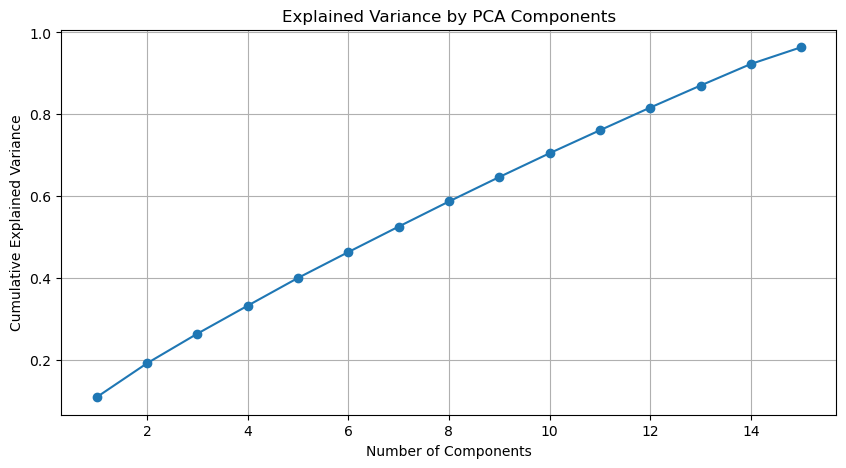

In [135]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()


In [136]:
os.makedirs("Data", exist_ok=True)  # create directory if it doesn't exist
pca_df = pd.DataFrame(pca_data)
pca_df.to_csv("../Data/clean_data.csv", index=False)